## A-Random Forest (Same model used in original RF notebook + Explainability methods with plots)

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 120, "font.family": "sans-serif", "axes.spines.top": False, "axes.spines.right": False})
print("All libraries loaded.")

All libraries loaded.


## 2. Load and Inspect the Dataset

In [2]:
raw_data, meta = arff.loadarff("dataset_31_credit-g.arff")
df = pd.DataFrame(raw_data)
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.decode("utf-8")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: 1000 rows x 21 columns
Missing values: 0


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [3]:
print(df.dtypes)

checking_status            object
duration                  float64
credit_history             object
purpose                    object
credit_amount             float64
savings_status             object
employment                 object
installment_commitment    float64
personal_status            object
other_parties              object
residence_since           float64
property_magnitude         object
age                       float64
other_payment_plans        object
housing                    object
existing_credits          float64
job                        object
num_dependents            float64
own_telephone              object
foreign_worker             object
class                      object
dtype: object


Class distribution:
class
good    700
bad     300
Name: count, dtype: int64


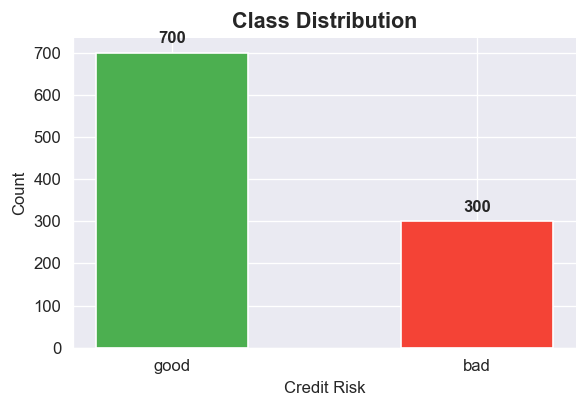

In [4]:
print("Class distribution:")
print(df["class"].value_counts())

fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df["class"].value_counts()
bars = ax.bar(counts.index, counts.values, color=["#4CAF50", "#F44336"], edgecolor="white", width=0.5)
ax.bar_label(bars, fmt="%d", padding=4, fontweight="bold")
ax.set_title("Class Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Credit Risk")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 3. Preprocessing - Encode Categorical Features

In [5]:
df_encoded = df.copy()
label_encoders = {}
categorical_cols = df_encoded.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print(f"Encoded {len(categorical_cols)} categorical columns:")
print(categorical_cols)
df_encoded.head()

Encoded 14 categorical columns:
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker', 'class']


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,1,6.0,1,6,1169.0,4,3,4.0,3,2,...,3,67.0,1,1,2.0,1,1.0,1,1,1
1,0,48.0,3,6,5951.0,2,0,2.0,0,2,...,3,22.0,1,1,1.0,1,1.0,0,1,0
2,3,12.0,1,2,2096.0,2,1,2.0,3,2,...,3,49.0,1,1,1.0,3,2.0,0,1,1
3,1,42.0,3,3,7882.0,2,1,2.0,3,1,...,1,45.0,1,0,1.0,1,2.0,0,1,1
4,1,24.0,2,4,4870.0,2,0,3.0,3,2,...,2,53.0,1,0,2.0,1,2.0,0,1,0


## 4. Train / Test Split

In [6]:
X = df_encoded.drop(columns=["class"])
y = df_encoded["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 700
Testing  samples : 300
Features         : 20


## 5. Train the Random Forest

In [7]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Random Forest trained.")
print(f"  Trees         : {rf.n_estimators}")
print(f"  Features used : {rf.n_features_in_}")

Random Forest trained.
  Trees         : 200
  Features used : 20


## 6. Evaluate Performance

In [8]:
y_pred = rf.predict(X_test)

le_class = label_encoders["class"]
target_names = le_class.classes_

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy : 0.7300  (73.00%)

Classification Report:
              precision    recall  f1-score   support

         bad       0.57      0.41      0.48        90
        good       0.77      0.87      0.82       210

    accuracy                           0.73       300
   macro avg       0.67      0.64      0.65       300
weighted avg       0.71      0.73      0.72       300



## 7. Confusion Matrix

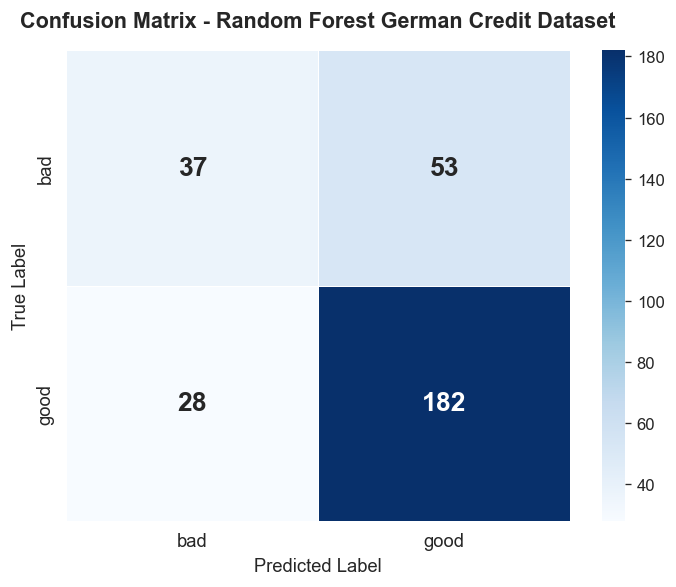

True  Negatives (bad  -> bad)  : 37
False Positives (bad  -> good) : 53
False Negatives (good -> bad)  : 28
True  Positives (good -> good) : 182


In [9]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, linecolor="white",
    xticklabels=target_names, yticklabels=target_names,
    ax=ax, annot_kws={"size": 16, "weight": "bold"}
)
ax.set_title("Confusion Matrix - Random Forest German Credit Dataset", fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
ax.tick_params(axis="both", labelsize=11)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True  Negatives (bad  -> bad)  : {tn}")
print(f"False Positives (bad  -> good) : {fp}")
print(f"False Negatives (good -> bad)  : {fn}")
print(f"True  Positives (good -> good) : {tp}")

## 8. Explainability (Random Forest): SHAP + Anchors


## Case Picker

In [10]:
class_names = list(label_encoders["class"].classes_)
bad_label = class_names.index("bad")
good_label = class_names.index("good")

pred = rf.predict(X_test)

bad_idxs = np.where(pred == bad_label)[0]
good_idxs = np.where(pred == good_label)[0]
mis_idxs = np.where(pred != y_test.values)[0]

bad_i = int(bad_idxs[0]) if len(bad_idxs) else None
good_i = int(good_idxs[0]) if len(good_idxs) else None
mis_i = int(mis_idxs[0]) if len(mis_idxs) else None

print("Selected indices in RF test set:")
print("  BAD predicted:", bad_i)
print("  GOOD predicted:", good_i)
print("  Misclassified:", mis_i)

Selected indices in RF test set:
  BAD predicted: 4
  GOOD predicted: 0
  Misclassified: 0


## SHAP + Plots

C:\Users\cezar\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


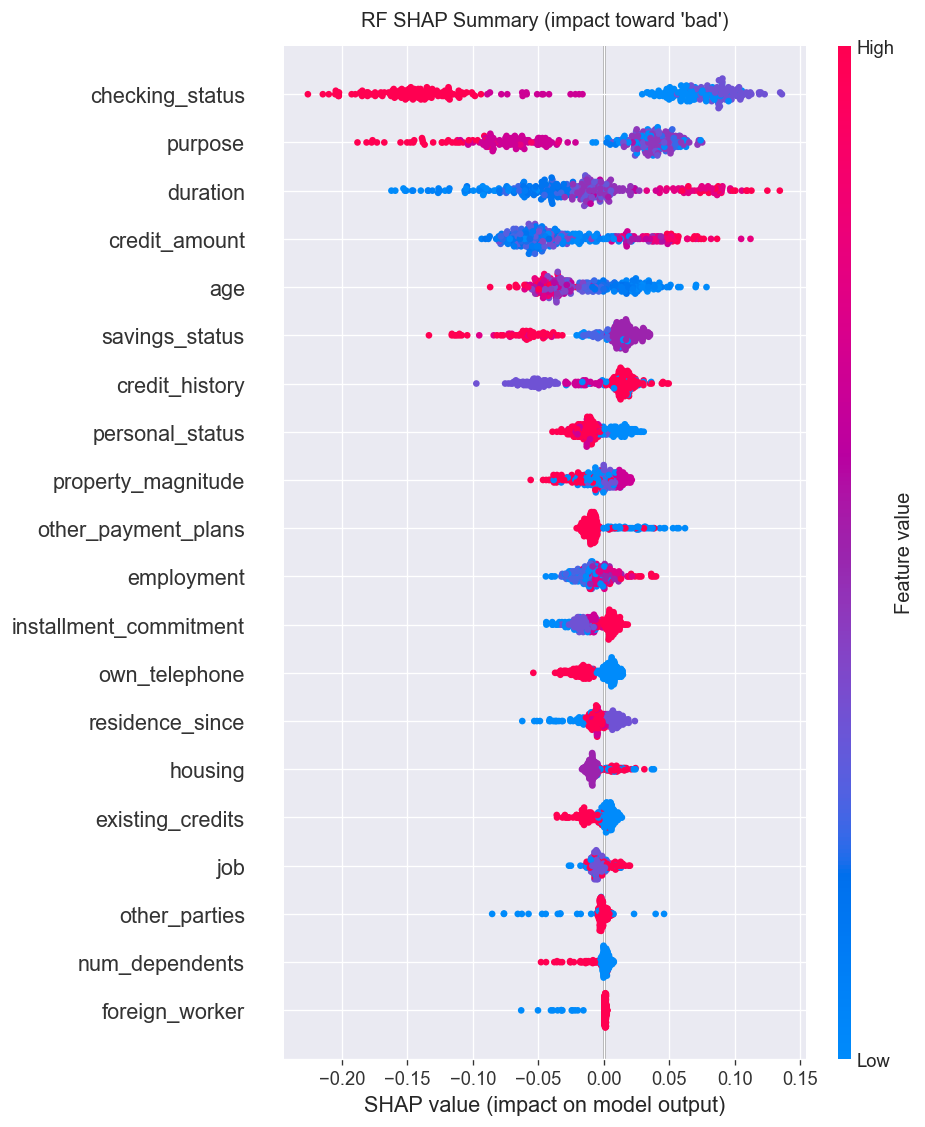

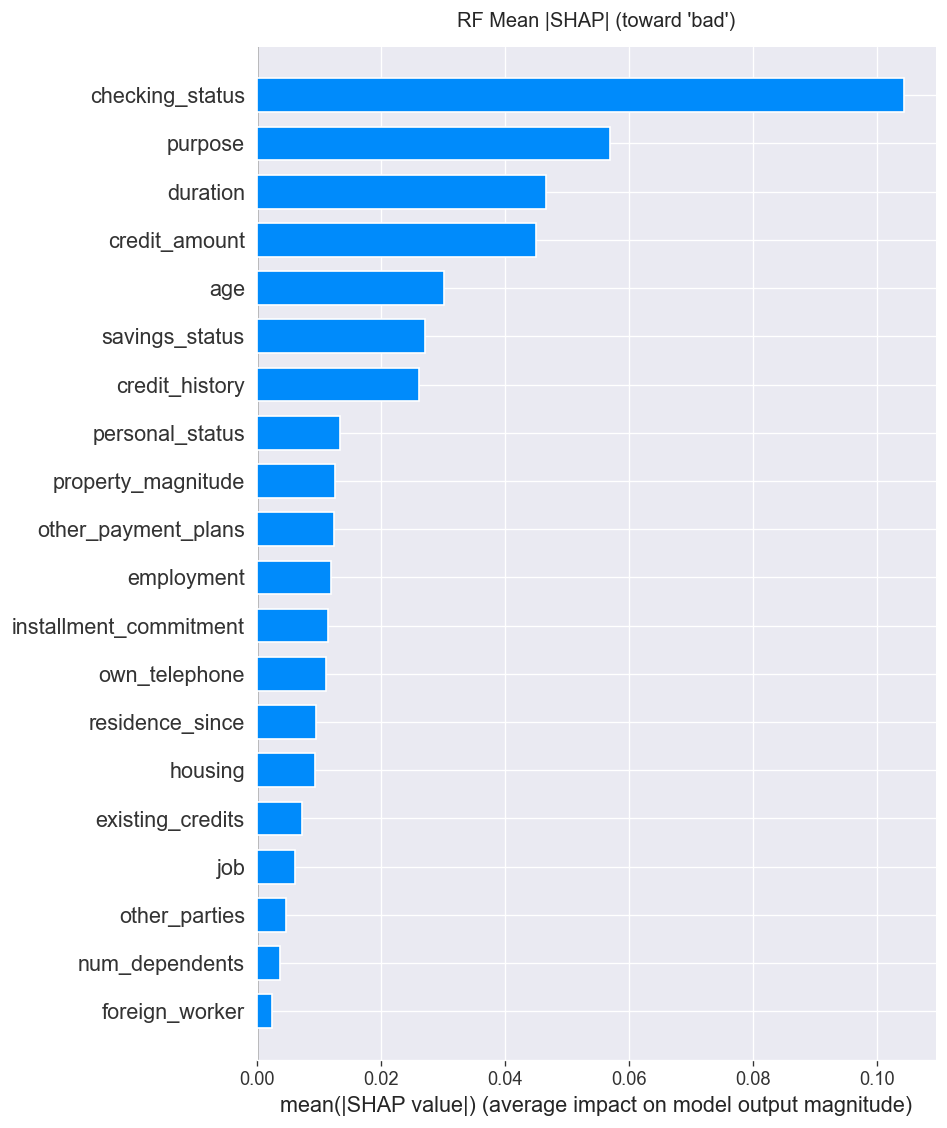

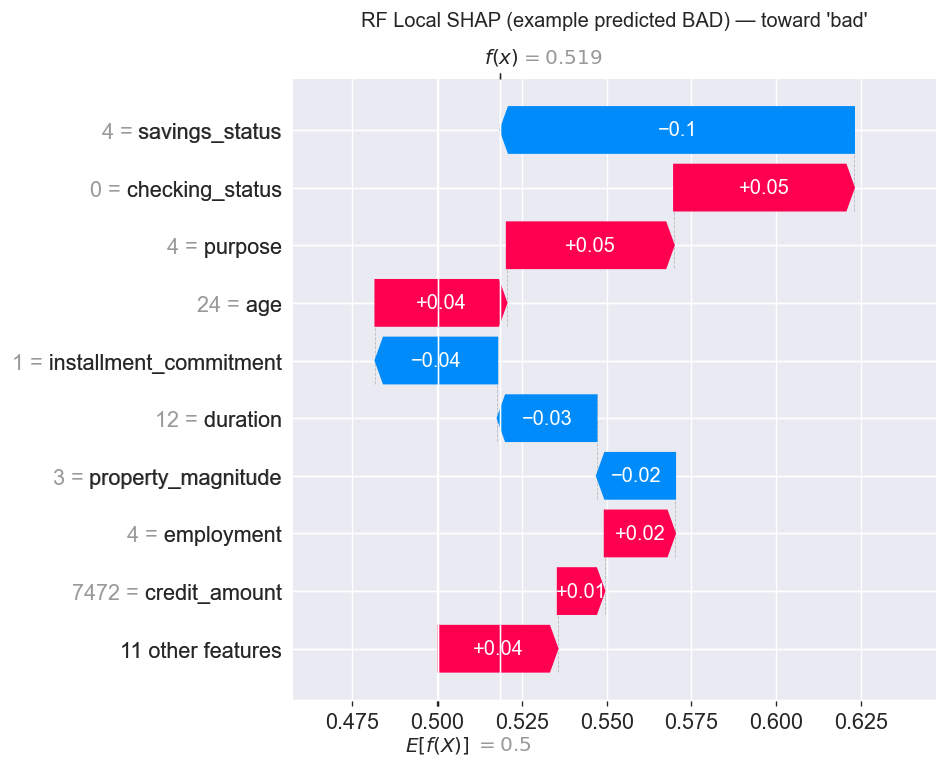

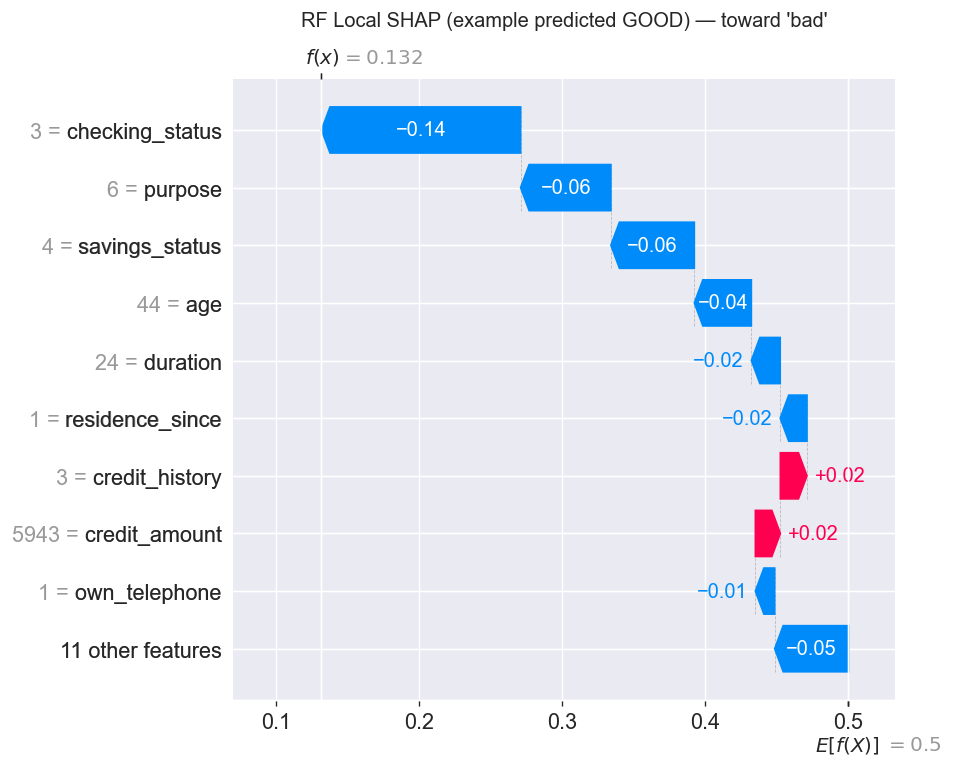

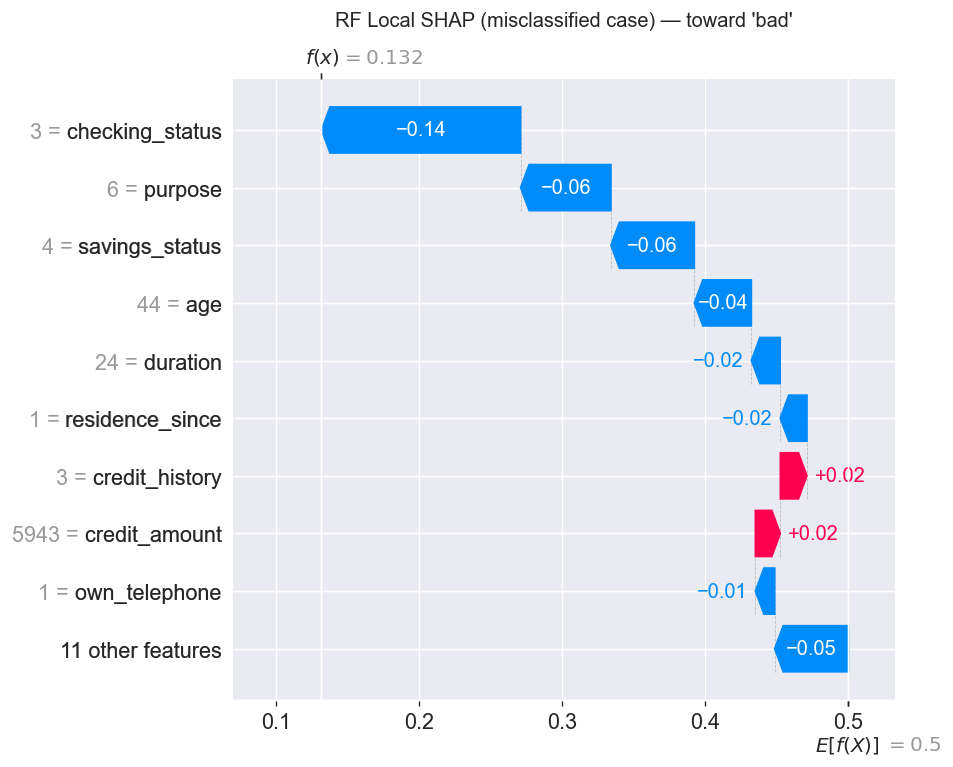

In [11]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

def get_shap_for_class(shap_values, class_index: int):
    if isinstance(shap_values, list):
        return shap_values[class_index]
    return shap_values[:, :, class_index]

# contributions toward BAD
sv_bad = get_shap_for_class(shap_values, bad_label)

# global summary
shap.summary_plot(sv_bad, X_test, show=False)
plt.title("RF SHAP Summary (impact toward 'bad')", pad=12)
plt.tight_layout()
plt.show()

# global importance
shap.summary_plot(sv_bad, X_test, plot_type="bar", show=False)
plt.title("RF Mean |SHAP| (toward 'bad')", pad=12)
plt.tight_layout()
plt.show()

#waterfall plots local
base = explainer.expected_value[bad_label] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

def shap_waterfall(idx, title):
    ex = shap.Explanation(
        values=sv_bad[idx],
        base_values=base,
        data=X_test.iloc[idx],
        feature_names=X_test.columns
    )
    shap.plots.waterfall(ex, show=False)
    plt.title(title, pad=12)
    plt.tight_layout()
    plt.show()

if bad_i is not None:
    shap_waterfall(bad_i, "RF Local SHAP (example predicted BAD) — toward 'bad'")

if good_i is not None:
    shap_waterfall(good_i, "RF Local SHAP (example predicted GOOD) — toward 'bad'")

if mis_i is not None:
    shap_waterfall(mis_i, "RF Local SHAP (misclassified case) — toward 'bad'")

## ANCHOR outputs (rules determined)

In [12]:

import numpy as np
import pandas as pd
from alibi.explainers import AnchorTabular

#check same feature space

print("rf.n_features_in_:", rf.n_features_in_)
print("X_train.shape[1] :", X_train.shape[1])

if rf.n_features_in_ != X_train.shape[1]:
    raise ValueError(

    )

feature_names = list(X_train.columns)
X_train_np = X_train.to_numpy()
X_test_np  = X_test.to_numpy()


#names as strings

categorical_cols_original = df.select_dtypes(include="object").columns.tolist()
categorical_cols_original = [c for c in categorical_cols_original if c != "class"]

categorical_names = {}
for c in categorical_cols_original:
    if c in feature_names and c in label_encoders:
        idx = feature_names.index(c)
        categorical_names[idx] = list(label_encoders[c].classes_)  # strings


#numpy to df to preserve feature names

def predict_fn_proba(x):
    x = np.asarray(x)
    if x.ndim == 1:
        x = x.reshape(1, -1)
    x_df = pd.DataFrame(x, columns=feature_names)
    return rf.predict_proba(x_df)

#created and fitted explainer
anchor_explainer = AnchorTabular(
    predictor=predict_fn_proba,
    feature_names=feature_names,
    categorical_names=categorical_names,
    seed=RANDOM_STATE
)
anchor_explainer.fit(X_train_np)

#examples
class_names = list(label_encoders["class"].classes_)
bad_label = class_names.index("bad")
good_label = class_names.index("good")

pred = rf.predict(X_test)

bad_candidates = np.where(pred == bad_label)[0]
good_candidates = np.where(pred == good_label)[0]
mis_candidates  = np.where(pred != y_test.values)[0]

bad_i  = int(bad_candidates[0]) if len(bad_candidates) else None
good_i = int(good_candidates[0]) if len(good_candidates) else None

# pick a misclassified index that is not equal to bad_i or good_i
mis_i = None
for idx in mis_candidates:
    idx = int(idx)
    if idx != bad_i and idx != good_i:
        mis_i = idx
        break

print("Selected indices in RF test set:", {"bad": bad_i, "good": good_i, "mis": mis_i})

#explain with auto-threshold fallback
def print_anchor(idx, thresholds=(0.95, 0.90, 0.85, 0.80), beam_size=100):
    x = X_test_np[idx]
    pred_label = int(rf.predict(X_test.iloc[[idx]])[0])

    best_exp = None
    best_prec = -1.0
    best_t = None

    for t in thresholds:
        exp = anchor_explainer.explain(
            x,
            threshold=t,
            beam_size=beam_size,
            stop_on_first=False,
            max_anchor_size=6,
            coverage_samples=2000,
            batch_size=200
        )

        anchor_list = exp.data.get("anchor", [])
        prec = float(np.array(exp.data.get("precision")).ravel()[0]) if exp.data.get("precision") is not None else -1.0

        #track best, in case anchors are empty at all thresholds
        if prec > best_prec:
            best_exp, best_prec, best_t = exp, prec, t

        #we accept only non empty anchors, and prefer the ones who hit our thersholds  thershold
        if anchor_list and prec >= t:
            print("\n" + "="*80)
            print("Index:", idx, "| RF prediction:", class_names[pred_label])
            print("Target precision threshold:", t)
            print("Anchor rule:")
            print("  " + " AND ".join(anchor_list))
            print("Precision:", prec)
            print("Coverage :", exp.data.get("coverage"))
            return exp

    # if we got here: no threshold was met; print best non-eligible result
    anchor_list = best_exp.data.get("anchor", []) if best_exp is not None else []
    print("\n" + "="*80)
    print("Index:", idx, "| RF prediction:", class_names[pred_label])
    print("No rule met the requested thresholds; showing best found rule instead.")
    print("Best attempted threshold:", best_t)
    print("Anchor rule:")
    print("  " + (" AND ".join(anchor_list) if anchor_list else "(EMPTY)"))
    print("Precision:", best_prec)
    print("Coverage :", best_exp.data.get("coverage") if best_exp is not None else None)
    return best_exp

if bad_i is not None:
    print_anchor(bad_i)

if good_i is not None:
    print_anchor(good_i)

if mis_i is not None:
    print_anchor(mis_i)


rf.n_features_in_: 20
X_train.shape[1] : 20
Selected indices in RF test set: {'bad': 4, 'good': 0, 'mis': 8}


Could not find an result satisfying the 0.95 precision constraint. Now returning the best non-eligible result.
Could not find an result satisfying the 0.9 precision constraint. Now returning the best non-eligible result.



Index: 4 | RF prediction: bad
Target precision threshold: 0.85
Anchor rule:
  age <= 27.00 AND personal_status = female div/dep/mar AND credit_amount > 3965.25 AND purpose = new car AND 0<=X<200 AND credit_history = existing paid
Precision: 0.8664955070603337
Coverage : 0.2885714285714286

Index: 0 | RF prediction: good
Target precision threshold: 0.95
Anchor rule:
  age > 33.00 AND checking_status = no checking
Precision: 0.966903073286052
Coverage : 0.4757142857142857

Index: 8 | RF prediction: good
Target precision threshold: 0.95
Anchor rule:
  duration <= 24.00 AND checking_status = no checking
Precision: 0.95260663507109
Coverage : 0.7628571428571429


## B-Decision Tree Model (same used in original DT notebook) + EXAI methods

In [13]:
import pandas as pd
from scipy.io import arff
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [14]:
data, meta = arff.loadarff('dataset_31_credit-g.arff')

df = pd.DataFrame(data)

for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = df[col].str.decode('utf-8')
        except:
            pass

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [15]:
X = df.drop(columns=['class'])
y = df['class']

#encoder
le = LabelEncoder()
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=['object']).columns:
    X_encoded[col] = le.fit_transform(X_encoded[col])

y_encoded = le.fit_transform(y)
class_names = le.classes_

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.3, random_state=42)

clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

print(f"Train accuracy: {accuracy_score(y_train, clf.predict(X_train)):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test, clf.predict(X_test)):.4f}")

Train accuracy: 0.7771
Test accuracy:  0.7033


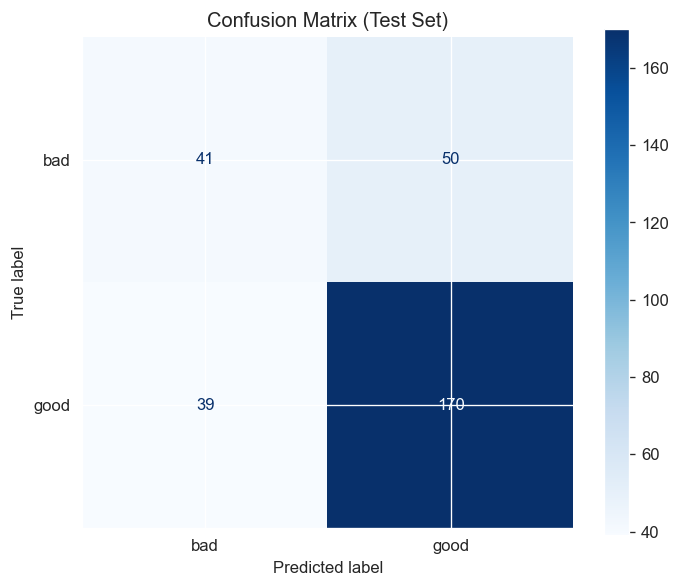

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()


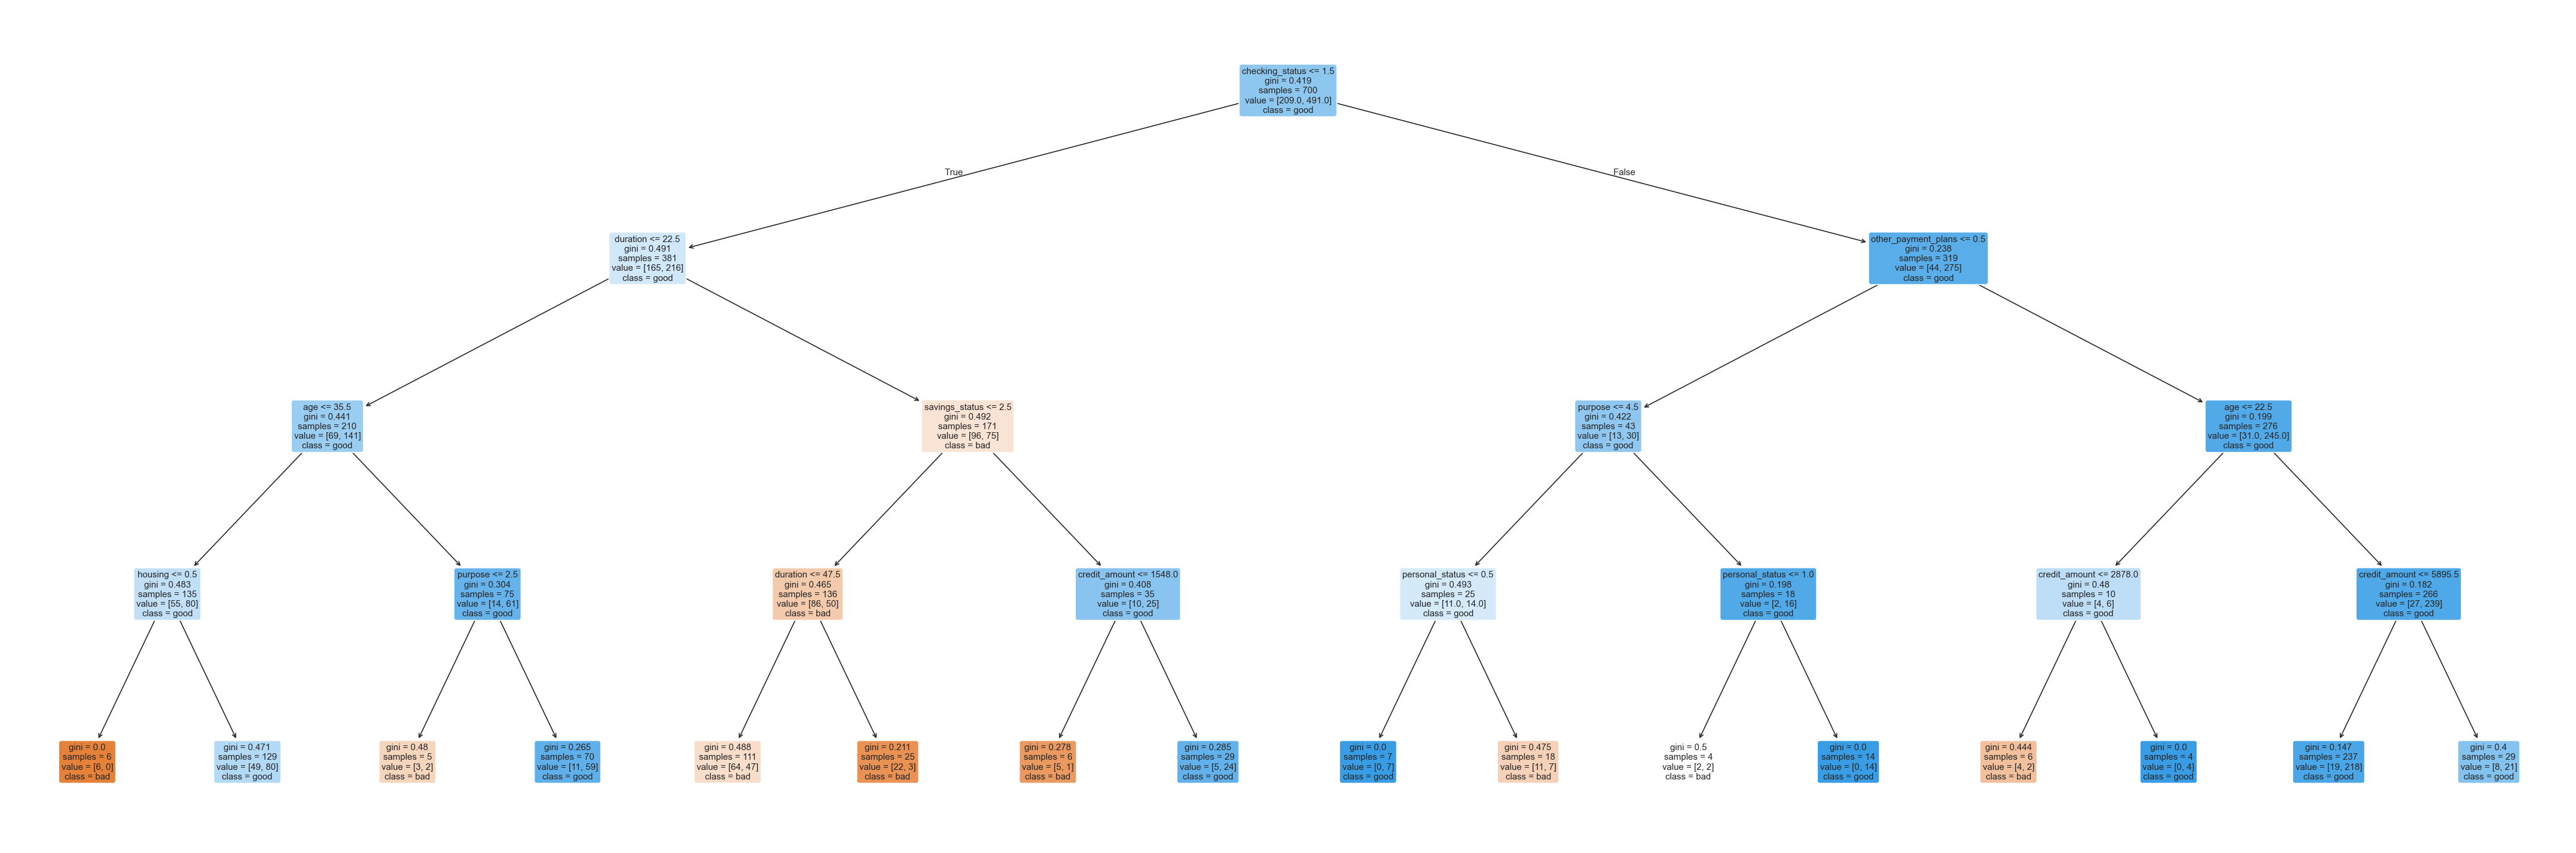

In [18]:
fig, ax = plt.subplots(figsize=(36, 12))

plot_tree(
    clf,
    feature_names=X_encoded.columns.tolist(),
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)

plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
from sklearn.tree import export_text

rules = export_text(clf, feature_names=X_encoded.columns.tolist())
print(rules[:6000])

|--- checking_status <= 1.50
|   |--- duration <= 22.50
|   |   |--- age <= 35.50
|   |   |   |--- housing <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- housing >  0.50
|   |   |   |   |--- class: 1
|   |   |--- age >  35.50
|   |   |   |--- purpose <= 2.50
|   |   |   |   |--- class: 0
|   |   |   |--- purpose >  2.50
|   |   |   |   |--- class: 1
|   |--- duration >  22.50
|   |   |--- savings_status <= 2.50
|   |   |   |--- duration <= 47.50
|   |   |   |   |--- class: 0
|   |   |   |--- duration >  47.50
|   |   |   |   |--- class: 0
|   |   |--- savings_status >  2.50
|   |   |   |--- credit_amount <= 1548.00
|   |   |   |   |--- class: 0
|   |   |   |--- credit_amount >  1548.00
|   |   |   |   |--- class: 1
|--- checking_status >  1.50
|   |--- other_payment_plans <= 0.50
|   |   |--- purpose <= 4.50
|   |   |   |--- personal_status <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- personal_status >  0.50
|   |   |   |   |--- class: 0
|   |   |--- purpose >  4.50
|

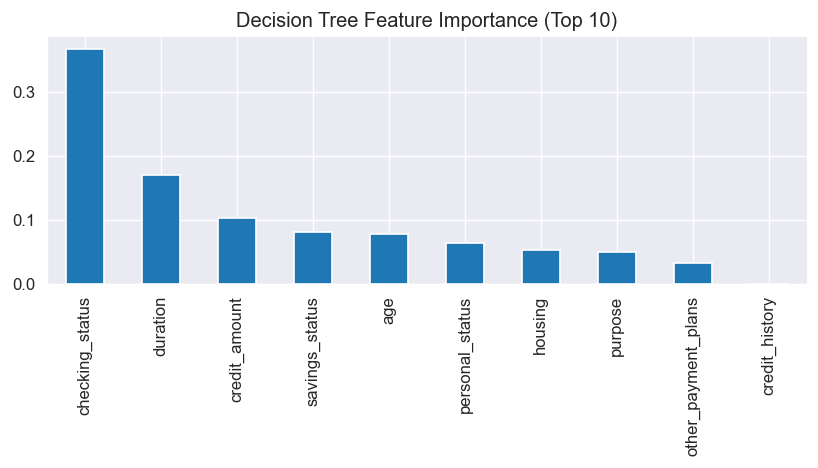

checking_status           0.367555
duration                  0.169826
credit_amount             0.102745
savings_status            0.081286
age                       0.077963
personal_status           0.064644
housing                   0.053587
purpose                   0.049753
other_payment_plans       0.032642
credit_history            0.000000
installment_commitment    0.000000
employment                0.000000
property_magnitude        0.000000
residence_since           0.000000
other_parties             0.000000
dtype: float64

In [20]:
import pandas as pd

imp = pd.Series(clf.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
imp.head(10).plot(kind="bar")
plt.title("Decision Tree Feature Importance (Top 10)")
plt.tight_layout()
plt.show()

imp.head(15)

In [21]:
from sklearn.tree import _tree

def explain_dt_path(model, x_row: pd.Series):
    tree = model.tree_
    feature_names = list(x_row.index)

    node_id = 0
    path = []

    while tree.feature[node_id] != _tree.TREE_UNDEFINED:
        f_idx = tree.feature[node_id]
        thresh = tree.threshold[node_id]
        f_name = feature_names[f_idx]
        val = x_row.iloc[f_idx]

        if val <= thresh:
            path.append(f"{f_name} <= {thresh:.3f}  (value={val})")
            node_id = tree.children_left[node_id]
        else:
            path.append(f"{f_name} > {thresh:.3f}  (value={val})")
            node_id = tree.children_right[node_id]

    pred = int(model.predict(x_row.values.reshape(1, -1))[0])
    proba = model.predict_proba(x_row.values.reshape(1, -1))[0]
    return path, pred, proba

#uses one pred bad and one pred good
dt_pred = clf.predict(X_test)

bad_label = int(np.where(class_names == "bad")[0][0]) if "bad" in list(class_names) else 0
good_label = int(np.where(class_names == "good")[0][0]) if "good" in list(class_names) else 1

bad_idxs = np.where(dt_pred == bad_label)[0]
good_idxs = np.where(dt_pred == good_label)[0]

bad_i = int(bad_idxs[0]) if len(bad_idxs) else None
good_i = int(good_idxs[0]) if len(good_idxs) else None

print("DT selected indices within DT test set:", {"bad": bad_i, "good": good_i})

def show_dt_explanation(i, title):
    path, pred, proba = explain_dt_path(clf, X_test.iloc[i])
    print("\n" + "="*80)
    print(title)
    print("Prediction:", class_names[pred], "| proba:", proba)
    print("Decision path:")
    for step in path:
        print(" -", step)

if bad_i is not None:
    show_dt_explanation(bad_i, "DT Local Explanation (example predicted BAD)")

if good_i is not None:
    show_dt_explanation(good_i, "DT Local Explanation (example predicted GOOD)")

DT selected indices within DT test set: {'bad': 2, 'good': 0}

DT Local Explanation (example predicted BAD)
Prediction: bad | proba: [0.57657658 0.42342342]
Decision path:
 - checking_status <= 1.500  (value=1.0)
 - duration > 22.500  (value=24.0)
 - savings_status <= 2.500  (value=0.0)
 - duration <= 47.500  (value=24.0)

DT Local Explanation (example predicted GOOD)
Prediction: good | proba: [0.37984496 0.62015504]
Decision path:
 - checking_status <= 1.500  (value=1.0)
 - duration <= 22.500  (value=18.0)
 - age <= 35.500  (value=24.0)
 - housing > 0.500  (value=1.0)


C:\Users\cezar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\cezar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\cezar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\cezar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [22]:
def rule_for_instance(model, X_df, idx: int):
    node_indicator = model.decision_path(X_df.iloc[[idx]])
    leave_id = model.apply(X_df.iloc[[idx]])

    feature = model.tree_.feature
    threshold = model.tree_.threshold
    features = X_df.columns

    node_index = node_indicator.indices[node_indicator.indptr[0]: node_indicator.indptr[1]]

    clauses = []
    for node_id in node_index:
        if node_id == leave_id[0]:
            continue
        f_id = feature[node_id]
        if f_id == _tree.TREE_UNDEFINED:
            continue
        f_name = features[f_id]
        thresh = threshold[node_id]
        val = X_df.iloc[idx, f_id]
        if val <= thresh:
            clauses.append(f"{f_name} <= {thresh:.3f}")
        else:
            clauses.append(f"{f_name} > {thresh:.3f}")

    pred = int(model.predict(X_df.iloc[[idx]])[0])
    return "IF " + " AND ".join(clauses) + f" THEN class = {class_names[pred]}"

if bad_i is not None:
    print("\nBAD instance rule:")
    print(rule_for_instance(clf, X_test, bad_i))

if good_i is not None:
    print("\nGOOD instance rule:")
    print(rule_for_instance(clf, X_test, good_i))


BAD instance rule:
IF checking_status <= 1.500 AND duration > 22.500 AND savings_status <= 2.500 AND duration <= 47.500 THEN class = bad

GOOD instance rule:
IF checking_status <= 1.500 AND duration <= 22.500 AND age <= 35.500 AND housing > 0.500 THEN class = good
